In [1]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [9]:
import pandas as pd
import re

from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/capetownfreeway.csv', encoding='ISO-8859-1')
df.head()

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str
0,0,Twitter Web Client,Update: Stationary Vehicle: N7 northbound befo...,NaN,False,Wed Jan 11 14:37:46 +0000 2017,1,819191575490297856
1,0,Twitter Web Client,"Crash: N2 outbound after Raapenberg, right lan...",NaN,False,Thu Jan 26 13:54:41 +0000 2017,1,824616552515395586
2,0,Twitter Web Client,Update: Congestion N2 Inbound at M3 Southbound...,NaN,False,Fri Jan 27 13:15:22 +0000 2017,0,824969046705725445
3,0,Twitter Web Client,Update: Stationary vehicle: N1 Outbound at Pla...,NaN,False,Wed Jan 25 12:36:11 +0000 2017,0,824234408358068225
4,0,Twitter Web Client,"Veldfire: N2 Inbound before Raapenberg, Left L...",NaN,False,Mon Jan 16 03:12:10 +0000 2017,1,820830979468181504


In [4]:
df.drop(['source', 'in_reply_to_screen_name', 'is_retweet'],
        axis=1, inplace=True)

In [5]:
def clean_tweet(tweet):
    no_link_loc = re.sub(r"http\S+", "", tweet)
    no_num_loc = no_link_loc.lower()
    for c in ['inbound','outbound','after','before','update','after','animals','roadworks',':',',',
              '#','@','savewater', 'boozefreeroads','speedkillsfacts','saferoadsforall', 'sharetheroad',
              'alwaysbuckleup', 'boozefreeroad','alwaysbuckleup','savekidslives','.','walksafe']:
        no_num_loc = no_num_loc.replace(c, '')

    no_num_loc = no_num_loc.split(',')[0]
    try:
        return no_num_loc
    except:
        pass

In [6]:
df['clean_tweet'] = df['text'].apply(clean_tweet)
df.head()

,favorite_count,text,created_at,retweet_count,id_str,clean_tweet
0,0,Update: Stationary Vehicle: N7 northbound befo...,Wed Jan 11 14:37:46 +0000 2017,1,819191575490297856,stationary vehicle n7 northbound bosmansdam ...
1,0,"Crash: N2 outbound after Raapenberg, right lan...",Thu Jan 26 13:54:41 +0000 2017,1,824616552515395586,crash n2 raapenberg right lane closed expect...
2,0,Update: Congestion N2 Inbound at M3 Southbound...,Fri Jan 27 13:15:22 +0000 2017,0,824969046705725445,congestion n2 at m3 southbound ramp is clear...
3,0,Update: Stationary vehicle: N1 Outbound at Pla...,Wed Jan 25 12:36:11 +0000 2017,0,824234408358068225,stationary vehicle n1 at plattekloof left la...
4,0,"Veldfire: N2 Inbound before Raapenberg, Left L...",Mon Jan 16 03:12:10 +0000 2017,1,820830979468181504,veldfire n2 raapenberg left lane closed driv...


In [7]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kerry\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

(-0.5, 799.5, 399.5, -0.5)

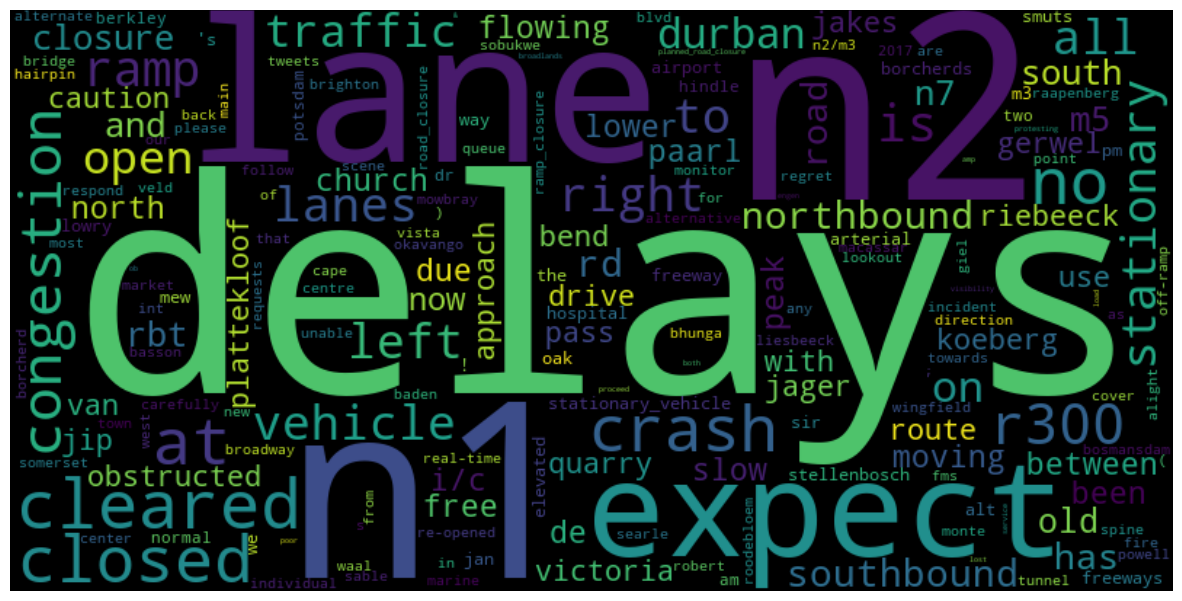

In [10]:
words = []
for i in df.clean_tweet:
    words.extend(word_tokenize(i))

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(frequencies = Counter(words))
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

In [11]:
vectorizer = TfidfVectorizer(max_df=0.8, max_features=50, stop_words='english')
X = vectorizer.fit_transform(df.clean_tweet).toarray()

In [12]:
vocab = vectorizer.get_feature_names_out()
print(vocab)

['church' 'cleared' 'closed' 'closure' 'congestion' 'crash' 'delays'
 'drive' 'durban' 'expect' 'flowing' 'free' 'jip' 'koeberg' 'lane' 'lanes'
 'left' 'lower' 'm3' 'm5' 'moving' 'n1' 'n2' 'n7' 'north' 'northbound'
 'obstructed' 'old' 'open' 'paarl' 'peak' 'plattekloof' 'quarry' 'r300'
 'ramp' 'rbt' 'rd' 'riebeeck' 'right' 'road' 'route' 'slow' 'south'
 'southbound' 'stationary' 'traffic' 'use' 'van' 'vehicle' 'victoria']


In [13]:
X = pd.DataFrame(X, columns=vocab)
print("n_samples: %d, n_features: %d" % X.shape)

n_samples: 24158, n_features: 50


In [21]:
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import preprocessing, decomposition

In [23]:
scaler = preprocessing.StandardScaler()
pca = decomposition.PCA(n_components=2)

print("Computing PCA projection")
t0 = time.time()
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled) 
t1 = time.time()
print("Finished PCA projection in " + str(t1-t0) + "s.") 

Computing PCA projection
Finished PCA projection in 0.3061034679412842s.


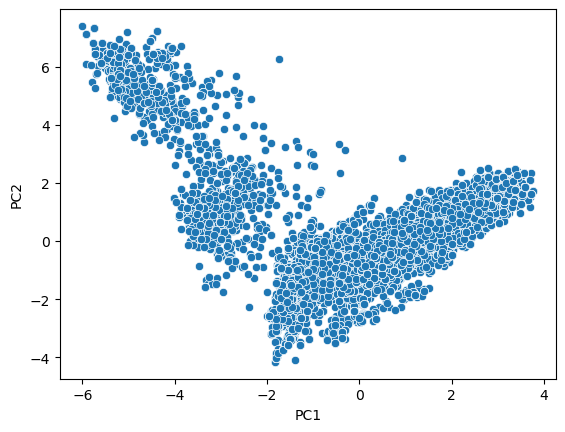

The first two principal components explain 15.0 % of the variance in the data


In [26]:
import seaborn as sns
import numpy as np
ax = sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()
print("The first two principal components explain " +
      str(np.round(sum(pca.explained_variance_ratio_[:2]),2)*100) + " % of the variance in the data")

In [27]:
import cufflinks as cf
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

In [28]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['text'] = df['clean_tweet']

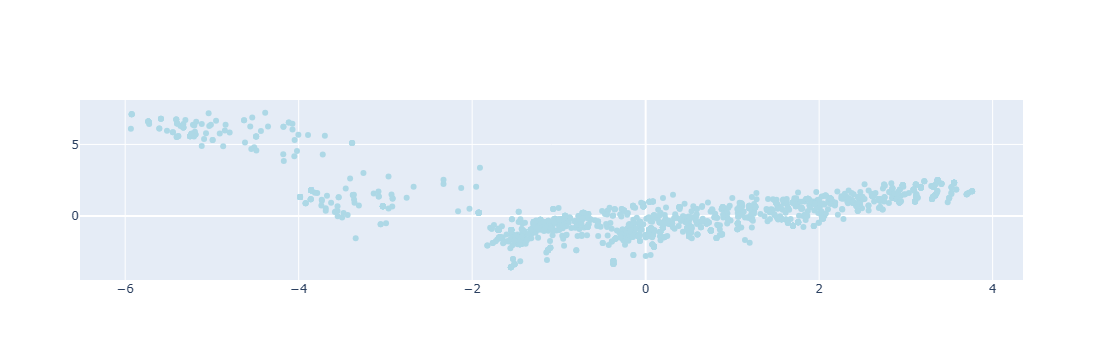

In [29]:
data = [
    go.Scatter(
        x = pca_df.iloc[:2000,0].values,
        y = pca_df.iloc[:2000,1].values,
        text = pca_df.iloc[:2000,2].values,
        hoverinfo = 'text',
        marker = dict(
            color = 'lightblue'
        ),
        mode='markers',
        showlegend = False
    )
]

iplot(data, filename = "add-hover-text")

In [31]:
# MDS
from sklearn.manifold import MDS
from sklearn import manifold
print("Computing MDS embedding")
mds = manifold.MDS(n_components=2,
                   n_init=2,
                   max_iter=200,
                   n_jobs=-1,
                   random_state=42,
                   dissimilarity='euclidean')
t0 = time.time()
X_mds = mds.fit_transform(X.iloc[:2000,:])
t1 = time.time()
print("Done. Stress: %f" % mds.stress_)

Computing MDS embedding
Done. Stress: 454048.166516


In [33]:
import pandas as pd
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# 1. Convert your MDS results (X_mds) into a DataFrame
mds_df = pd.DataFrame(X_mds, columns=['x', 'y'])

mds_df['label'] = X.iloc[:2000, 2].values

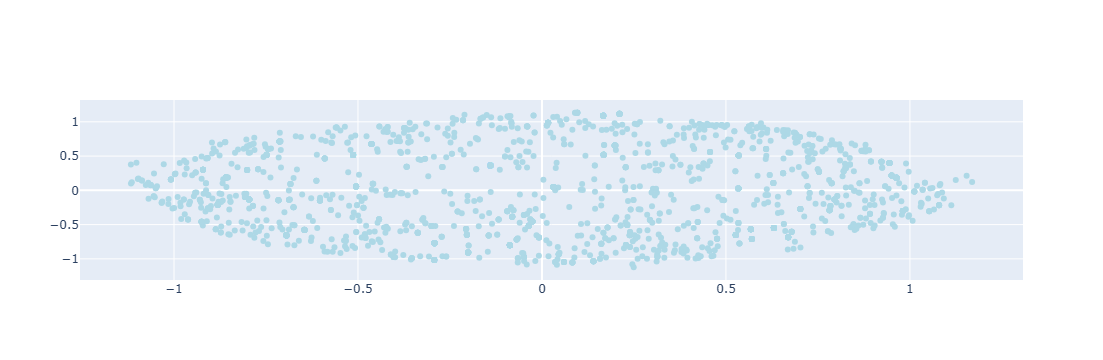

In [34]:
data = [
    go.Scatter(
        x = mds_df.iloc[:2000,0].values,
        y = mds_df.iloc[:2000,1].values,
        text = mds_df.iloc[:2000,2].values,
        hoverinfo = 'text',
        marker = dict(
            color = 'lightblue'
        ),
        mode='markers',
        showlegend = False
    )
]

iplot(data, filename = "add-hover-text")

In [36]:
# tSNE
from sklearn.manifold import TSNE
print("Computing t-SNE embedding")
tsne = manifold.TSNE(n_components=2,
                     perplexity=40,
                     metric='euclidean',
                     init='pca',
                     verbose=1,
                     random_state=42)
t0 = time.time()
X_tsne = tsne.fit_transform(X.iloc[:5000,:])
t1 = time.time()

Computing t-SNE embedding
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.002s...
[t-SNE] Computed neighbors for 5000 samples in 2.527s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.481186
[t-SNE] KL divergence after 1000 iterations: 0.422529


In [37]:
tsne_df = pd.DataFrame(X_tsne, columns=['D1', 'D2'])
tsne_df['text'] = df['clean_tweet']

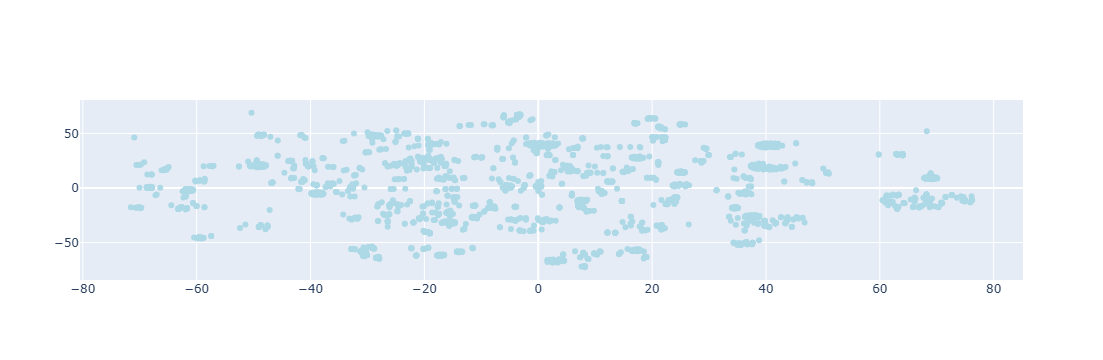

In [38]:
data = [
    go.Scatter(
        x = tsne_df.iloc[:2000,0].values,
        y = tsne_df.iloc[:2000,1].values,
        text = tsne_df.iloc[:2000,2].values,
        hoverinfo = 'text',
        marker = dict(
            color = 'lightblue'
        ),
        mode='markers',
        showlegend = False
    )
]

iplot(data, filename = "add-hover-text")